<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PR_PRACTICAL_5_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import cv2

In [2]:
digits = load_digits()

X = digits.images
y = digits.target

print("Total Images:", len(X))
print("Image Shape:", X[0].shape)

Total Images: 1797
Image Shape: (8, 8)


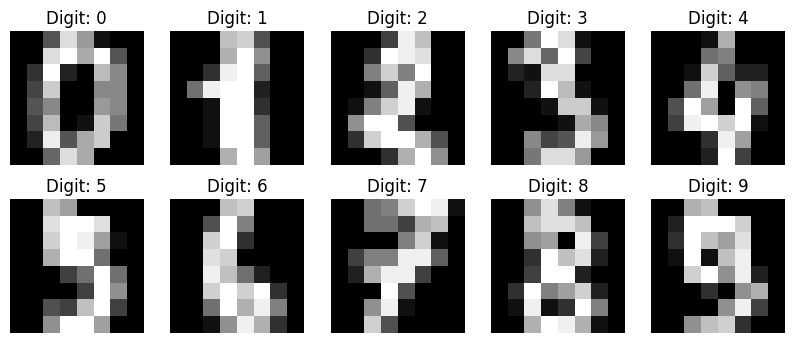

In [3]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title("Digit: "+str(y[i]))
    plt.axis("off")

plt.show()

In [4]:
features = []

for image in X:
    image = (image*16).astype(np.uint8)

    edges = cv2.Canny(image,50,150)

    feature = edges.flatten()

    features.append(feature)

features = np.array(features)

print(features.shape)

(1797, 64)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = SVC()

model.fit(X_train,y_train)

SVC()

In [7]:
predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.7


In [9]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.80      0.73      0.76        33
           1       0.52      0.61      0.56        28
           2       0.72      0.70      0.71        33
           3       0.64      0.68      0.66        34
           4       0.86      0.67      0.76        46
           5       0.81      0.64      0.71        47
           6       0.75      0.94      0.84        35
           7       0.71      0.79      0.75        34
           8       0.60      0.60      0.60        30
           9       0.59      0.65      0.62        40

    accuracy                           0.70       360
   macro avg       0.70      0.70      0.70       360
weighted avg       0.71      0.70      0.70       360



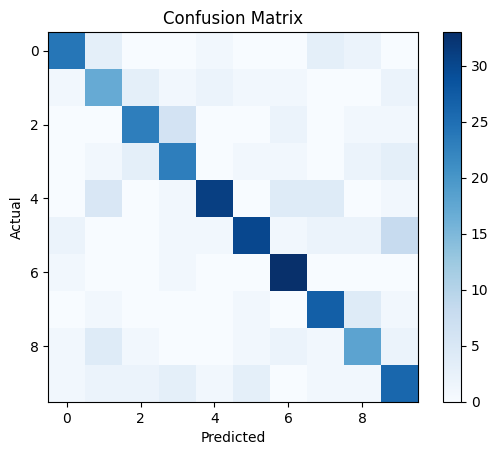

In [10]:
cm = confusion_matrix(y_test,predictions)

plt.imshow(cm,cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

Predicted: 7


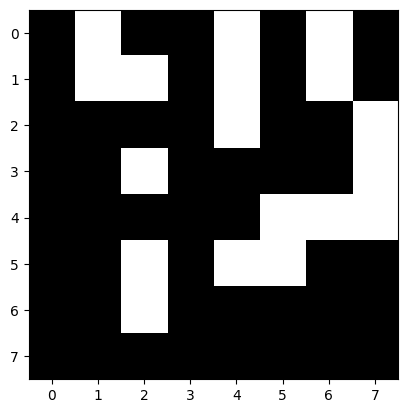

In [11]:
index = np.random.randint(0,len(X_test))

plt.imshow(X_test[index].reshape(8,8),cmap='gray')

print("Predicted:",model.predict([X_test[index]])[0])